<h1 style="color:red;">Numerical Simulation Laboratory - Exercise 4.3</h1>

The aim of this exercise is to investigate the apparent irreversibility of the Molecular Dynamics evolution observed in Exercise 4.2. Although the equations of motion are invariant under time reversal, the macroscopic evolution of a many-particle system appears to proceed spontaneously from the initial low-entropy state towards equilibrium. In this exercise, we test this reversibility numerically by starting from the final states of two simulations of Exercise 4.2, characterized by different numbers of time steps, and reversing the direction of time by changing the sign of all particle velocities.

If the dynamics were perfectly reversible, the system should retrace its previous trajectory and progressively return to the highly ordered, low-entropy initial configuration. In practice, however, the unavoidable numerical errors introduced during the integration are amplified by the chaotic dynamics of the system, so that the reversed trajectory is expected to progressively deviate from the original one.

To investigate this behaviour, the evolution of the **average potential energy**, **average kinetic energy** and **average temperature** will be monitored block by block, both in the original and in the reversed time direction. By comparing the two evolutions, we can determine how long the numerical trajectory remains approximately reversible and how rapidly it deviates from the original dynamics. The results will then be used to discuss the connection between microscopic time reversibility, numerical instability, and the macroscopic irreversibility observed in thermodynamic systems.

### Time-Reversed Simulation

To perform the time-reversal test, the `nsl_simulator` program was extended by introducing the `reverse` property, which allows the Molecular Dynamics simulation to evolve with the time direction reversed. The reversed simulation is initialized using the `config.xyz` and `config-1.xyz` files produced by the corresponding forward simulation. These files contain two consecutive configurations of the system and provide the two positions required by the Verlet algorithm.

In fact, the Verlet integration scheme is based on the relation

$$
\vec{r}(t+\Delta t)=2\vec{r}(t)-
\vec{r}(t - \Delta t)
+\vec{a}(t)\Delta t^2,
$$

where the new position is determined from the positions at two consecutive previous time steps and the acceleration evaluated at the current position. Therefore, by appropriately exchanging the two configurations and reversing the velocities, it is possible to initialize the integration in the opposite temporal direction without requiring a different integration algorithm.

In [29]:
import numpy as np
import matplotlib.pyplot as plt


def plot_forward_reverse(
    forward_files,
    reverse_files,
    labels,
    nsteps,
    total_steps,
    ylabel,
    title
):
    """
    Plot forward and reverse simulations in a 2x1 figure.

    The upper panel shows the forward evolution, while the lower
    panel shows the reverse evolution.

    Parameters
    ----------
    forward_files : list
        Filenames containing forward simulation data.
    reverse_files : list
        Filenames containing reverse simulation data.
    labels : list
        Labels associated with each physical quantity.
    nsteps : int
        Number of MD steps corresponding to one block.
    total_steps : int
        Total number of MD steps.
    ylabel : str
        Label for the y-axis.
    title : str
        Common title for the figure.
    """

    fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

    for forward_file, reverse_file, label in zip(
        forward_files, reverse_files, labels
    ):

        forward = np.loadtxt(forward_file, comments="#")
        reverse = np.loadtxt(reverse_file, comments="#")

        # Physical time for the forward simulation
        t_forward = np.arange(len(forward)) * nsteps

        # Physical time for the reverse simulation
        t_reverse = total_steps - np.arange(len(reverse)) * nsteps

        # Forward
        axs[0].plot(
            t_forward,
            forward[:, 1],
            label=label
        )

        # Reverse
        axs[1].plot(
            t_reverse,
            reverse[:, 1],
            label=label
        )

    axs[0].set_title("Forward")
    axs[1].set_title("Reverse")

    axs[0].set_ylabel(ylabel)
    axs[1].set_ylabel(ylabel)
    axs[1].set_xlabel("Time step")

    axs[0].legend()
    axs[1].legend()

    fig.suptitle(title)
    fig.tight_layout()

    plt.show()

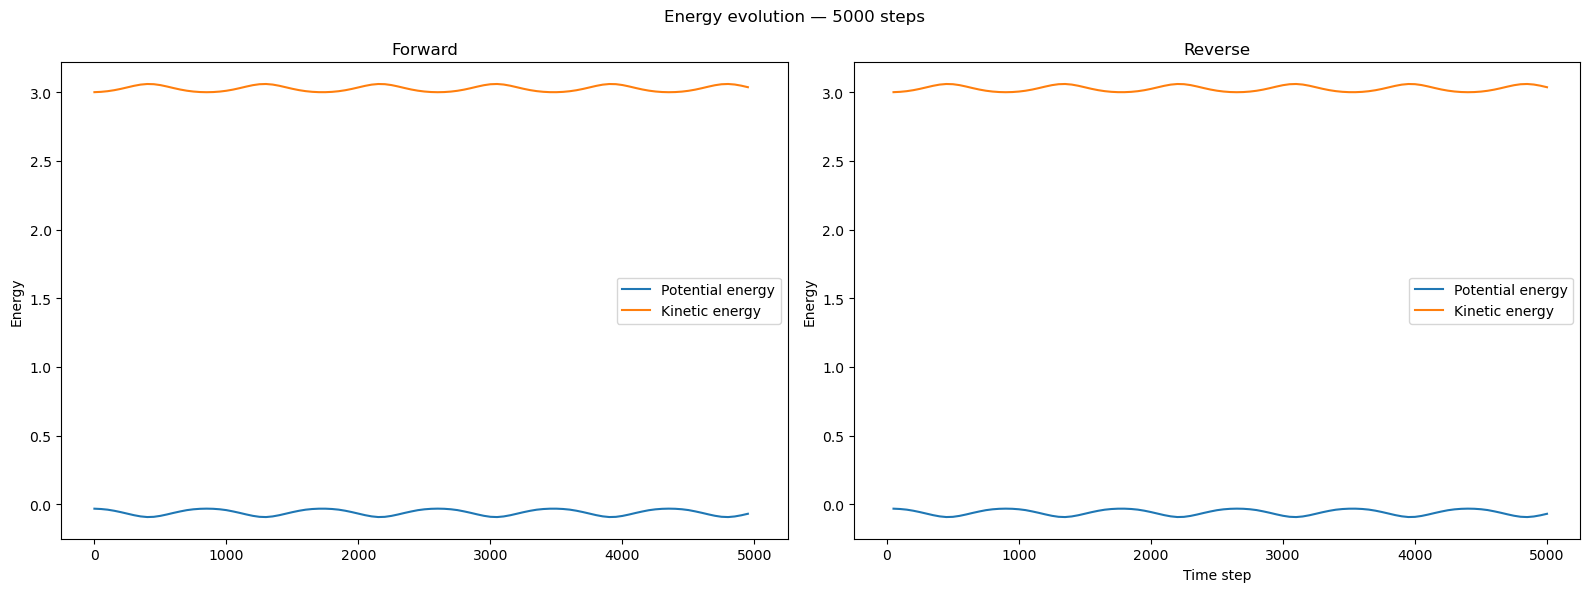

In [30]:
# 5000 steps - Energy

plot_forward_reverse(
    forward_files=[
        "nsl_simulator/NSL_SIMULATOR/OUTPUT/potential_energy_5000_forward.dat",
        "nsl_simulator/NSL_SIMULATOR/OUTPUT/kinetic_energy_5000_forward.dat"
    ],
    reverse_files=[
        "nsl_simulator/NSL_SIMULATOR/OUTPUT/potential_energy_5000_reverse.dat",
        "nsl_simulator/NSL_SIMULATOR/OUTPUT/kinetic_energy_5000_reverse.dat"
    ],
    labels=[
        "Potential energy",
        "Kinetic energy"
    ],
    nsteps=50,
    total_steps=5000,
    ylabel="Energy",
    title="Energy evolution — 5000 steps"
)

**Figure 1.** The figure compares the kinetic and potential energies obtained during the forward and time-reversed Molecular Dynamics simulations over $5000$ time steps. Both quantities remain approximately constant throughout the evolution, with only small fluctuations around their mean values. The kinetic and potential energies also exhibit opposite variations: when one increases slightly, the other tends to decrease by a corresponding amount. This behaviour reflects the exchange between kinetic and potential energy while the total energy of the system remains approximately conserved.

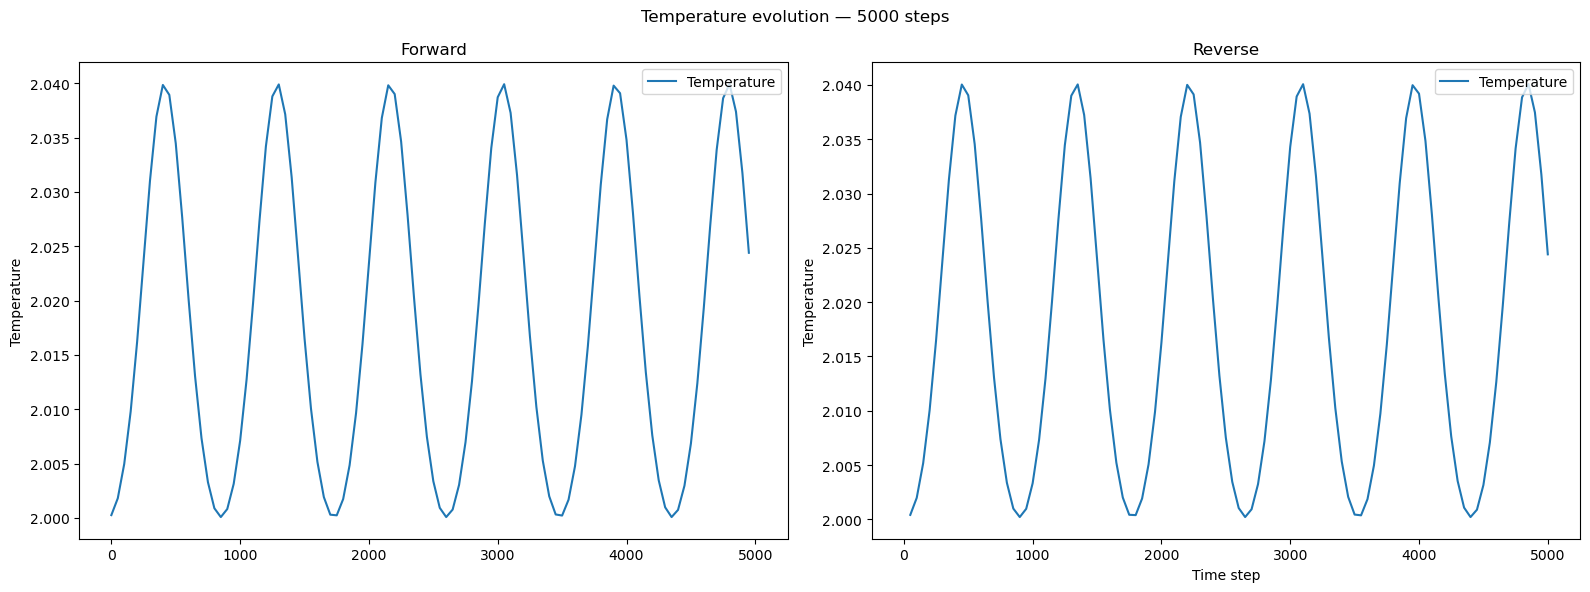

In [31]:
# 5000 steps — Temperature

plot_forward_reverse(
    forward_files=[
        "nsl_simulator/NSL_SIMULATOR/OUTPUT/temperature_5000_forward.dat"
    ],
    reverse_files=[
        "nsl_simulator/NSL_SIMULATOR/OUTPUT/temperature_5000_reverse.dat"
    ],
    labels=[
        "Temperature"
    ],
    nsteps=50,
    total_steps=5000,
    ylabel="Temperature",
    title="Temperature evolution — 5000 steps"
)

**Figure 2.** The figure shows the actual temperature measured in each block for the forward and time-reversed simulations over $5000$ time steps. In the forward evolution, the temperature starts from approximately $T^*=2.000$, increases up to about $T^*=2.040$, and then decreases again, producing regular oscillations around an average value close to $T^*\simeq2.02$. The reverse simulation exhibits a very similar oscillatory behaviour.. The two simulations therefore remain within a very similar temperature range throughout the evolution, with no significant systematic drift. This agreement indicates that, over the considered time interval, the time-reversed trajectory remains close to the original dynamics and that no significant loss of reversibility is yet visible from the temperature evolution.

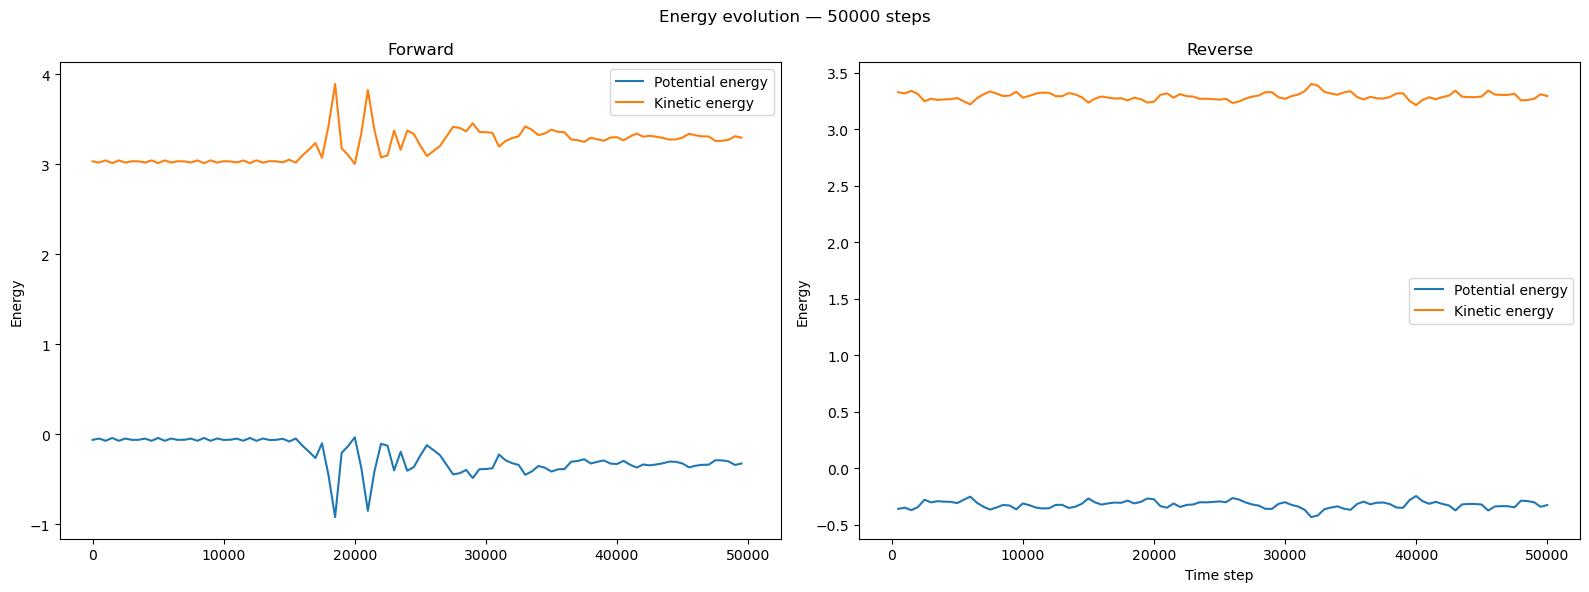

In [32]:
# 50000 steps — Energy

plot_forward_reverse(
    forward_files=[
        "nsl_simulator/NSL_SIMULATOR/OUTPUT/potential_energy_50000_forward.dat",
        "nsl_simulator/NSL_SIMULATOR/OUTPUT/kinetic_energy_50000_forward.dat"
    ],
    reverse_files=[
        "nsl_simulator/NSL_SIMULATOR/OUTPUT/potential_energy_50000_reverse.dat",
        "nsl_simulator/NSL_SIMULATOR/OUTPUT/kinetic_energy_50000_reverse.dat"
    ],
    labels=[
        "Potential energy",
        "Kinetic energy"
    ],
    nsteps=500,
    total_steps=50000,
    ylabel="Energy",
    title="Energy evolution — 50000 steps"
)

**Figure 3.** The figure shows the kinetic and potential energies measured during the forward and time-reversed Molecular Dynamics simulations over $50000$ time steps. In both simulations, the two contributions exhibit fluctuations around their respective mean values and show an approximately opposite behaviour: variations in the kinetic energy are accompanied by corresponding variations in the potential energy. This reflects the continuous exchange between kinetic and potential energy while the total energy of the system remains approximately conserved. The forward and reverse simulations display similar overall energy behaviour, although small differences progressively emerge due to the numerical errors accumulated during the integration and amplified by the chaotic dynamics of the system. Over this longer time interval, these deviations provide evidence of the gradual loss of exact numerical reversibility.

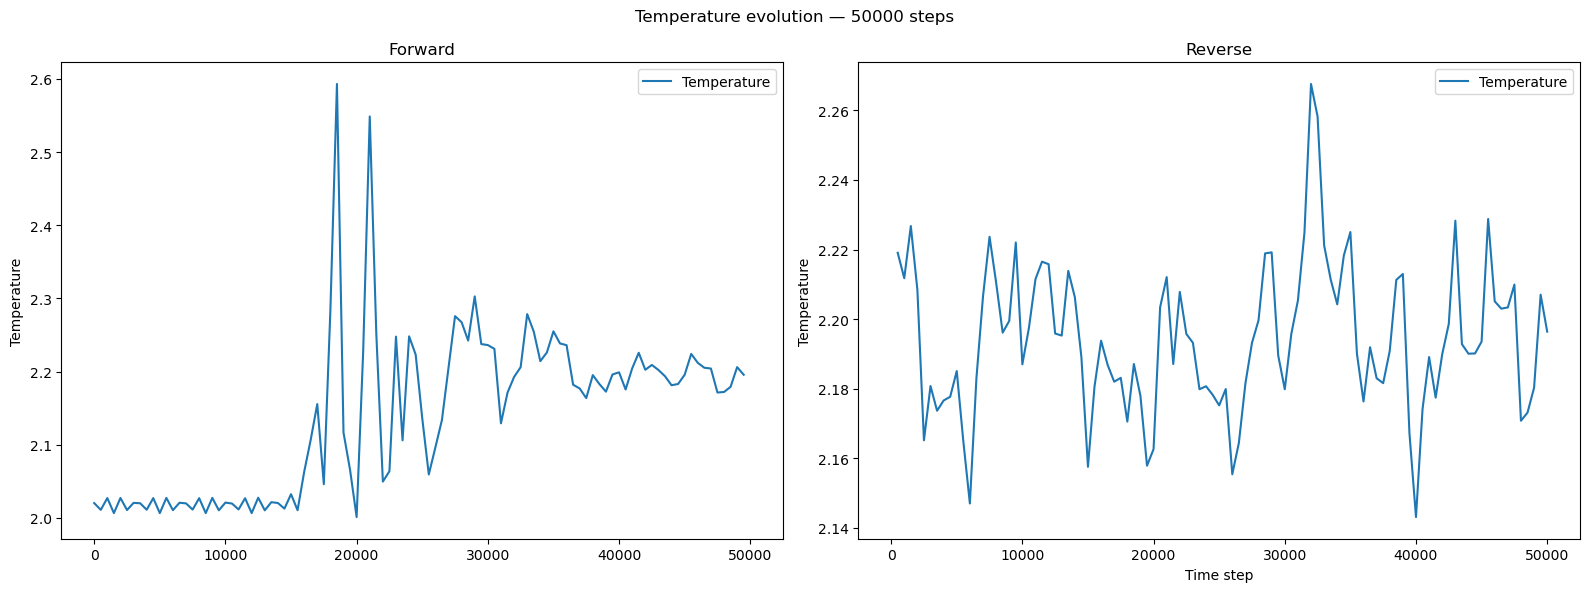

In [33]:
# 50000 steps — Temperature

plot_forward_reverse(
    forward_files=[
        "nsl_simulator/NSL_SIMULATOR/OUTPUT/temperature_50000_forward.dat"
    ],
    reverse_files=[
        "nsl_simulator/NSL_SIMULATOR/OUTPUT/temperature_50000_reverse.dat"
    ],
    labels=[
        "Temperature"
    ],
    nsteps=500,
    total_steps=50000,
    ylabel="Temperature",
    title="Temperature evolution — 50000 steps"
)

**Figure 4.** The figure shows the actual temperature measured in each block during the forward and time-reversed Molecular Dynamics simulations over $50000$ time steps. In the forward evolution, the temperature initially fluctuates around $T^*\simeq2.02$ and then increases significantly, reaching values around $T^*\simeq2.2$ before settling into fluctuations around a higher mean value. The reverse simulation starts from a temperature of approximately $T^*\simeq2.20$ and subsequently fluctuates around this value, without reproducing the temperature evolution observed in the forward simulation. Compared with the shorter simulation, the two trajectories therefore show a much more pronounced divergence. This behaviour is a consequence of the accumulation and amplification of numerical errors in the chaotic dynamics of the system, which progressively destroys the exact correspondence between the forward and time-reversed trajectories. Thus, over $50000$ time steps, the macroscopic evolution is no longer numerically reversible, despite the time-reversibility of the underlying equations of motion.

### Conclusion

The time-reversed simulations show that the microscopic equations of motion are, in principle, time-reversible: by reversing the particle velocities, the system can approximately retrace its previous trajectory. Over sufficiently long times, however, the small numerical errors introduced by the Verlet integration are amplified by the chaotic dynamics, causing the reversed trajectory to progressively deviate from the original one.

As a consequence, starting from an equilibrium configuration does not lead the system back to the highly ordered, low-entropy initial state. Such a spontaneous evolution towards a particular low-entropy configuration is statistically extremely unlikely, since equilibrium corresponds to a vastly larger number of accessible microscopic configurations.

This illustrates a fundamental distinction between microscopic reversibility and macroscopic irreversibility. Although Newton's equations are invariant under time reversal, macroscopic systems naturally evolve towards more probable, higher-entropy states, while a spontaneous decrease of entropy is overwhelmingly unlikely.